In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics.pairwise import cosine_similarity

In [3]:
full_df = pd.read_csv("umn_apartment_data.csv") #reading csv file

#spliting dataframes between amenities and other data points
df = full_df.iloc[:,:9]
amenities_df = full_df.iloc[:,9:]

#loop through all amenities to put into 1 list
temp_df = pd.DataFrame()
for index, values in amenities_df.iterrows():
    my_list = [values.unique()[:-1]]
    temp_df = pd.concat([temp_df, pd.Series(my_list)], ignore_index = True) #adding list into dataframe in each iteration

#recombining main df with modified amenities df
df = pd.concat([df, temp_df], axis = 1, ignore_index = True)

#renaming columns
column_list = ["Name", "Address", "Floor Plan", "Bedrooms", "Bathrooms", "Price", "Size", "Availability", "Link", "Amenities"]
column_dic = {}
for i in range(len(column_list)):
    column_dic[df.columns.values[i]] = column_list[i]

df = df.rename(columns = column_dic)

Potential Features:
- Location (Distance from a Central Point)
- Amount of Bathrooms/Beds
- Price
- Size
- Amenities (Specific ID for Each Kind)
- Shaping (potentially)

In [6]:
#replacing each value in Bedrooms column with numerical value
idx = 0
for value in df["Bedrooms"]:
    if value == "Studio":
        df.iloc[idx, 3] = "0"
    else:
        df.iloc[idx, 3] = value[0]
    idx += 1

#replacing each value in Price column with numerical value
idx = 0
for value in df["Price"]:
    end_id = value.find("-")
    try:
        df.iloc[idx, 5] = pd.to_numeric(value[1:end_id])
    except:
        df.iloc[idx, 5] = None
    idx += 1

#replacing each value in Size column with numerical value
# idx = 0
# for value in df["Size"]:
#     if type(value) is str:
#         end_id = value.find("-") + 1
#     try:
#         df.iloc[idx, 6] = pd.to_numeric(value[1:end_id])
#     except:
#         df.iloc[idx, 6] = None
#     idx += 1

Text(0, 0.5, 'Size')

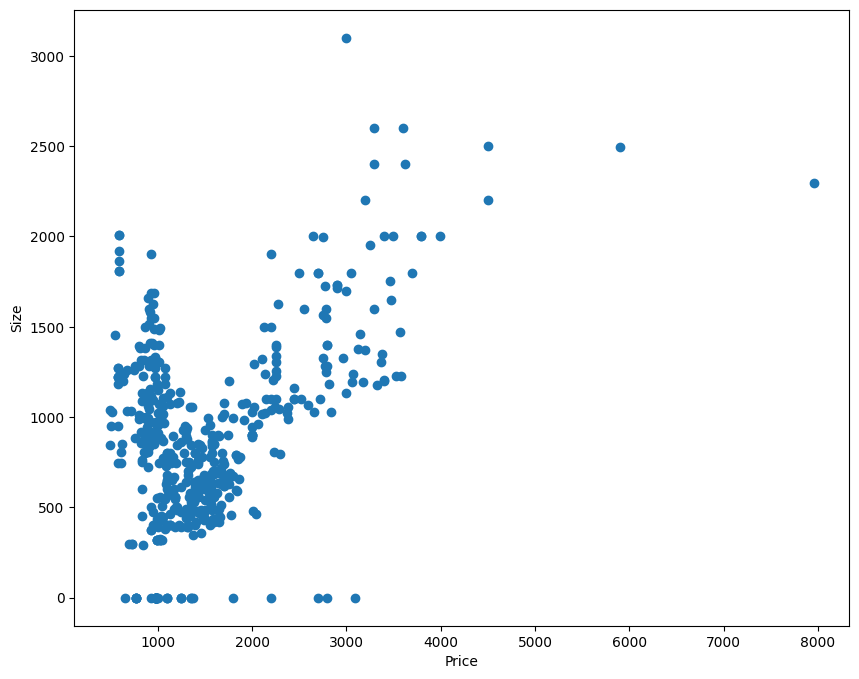

In [6]:
gs, ax = plt.subplots(figsize = (10,8))

plt.scatter(df.sort_values("Price")["Price"], df.sort_values("Price")["Size"])

plt.xlabel("Price")
plt.ylabel("Size")


In [8]:
#making each value numeric - if error occurs replaces value with NaN
df['Price'] = pd.to_numeric(df['Price'], errors='coerce')
df['Size'] = pd.to_numeric(df['Size'], errors='coerce')
df['Bathrooms'] = pd.to_numeric(df['Bathrooms'], errors='coerce')
df['Bedrooms'] = pd.to_numeric(df['Bedrooms'], errors='coerce')

df = df.dropna() #removing all none types

In [6]:
print(df[["Price", "Size", "Bathrooms", "Bedrooms"]].corr()) #correlation square

              Price      Size  Bathrooms  Bedrooms
Price      1.000000  0.610654   0.378208  0.509973
Size       0.610654  1.000000   0.645588  0.704942
Bathrooms  0.378208  0.645588   1.000000  0.715045
Bedrooms   0.509973  0.704942   0.715045  1.000000


In [ ]:
full_house_df = pd.read_csv("umn_housing_data.csv") #reading csv

In [ ]:
#spliting dataframes between amenities and other data points
house_df = full_house_df.iloc[:,:7]
house_amenities_df = full_house_df.iloc[:,7:]
house_amenities_df

#loop through all amenities to put into 1 list
temp_df = pd.DataFrame()
for index, values in house_amenities_df.iterrows():
    my_list = [values.unique()[:-1]]
    temp_df = pd.concat([temp_df, pd.Series(my_list)], ignore_index = True)

#recombining main df with modified amenities df
house_df = pd.concat([house_df, temp_df], axis = 1, ignore_index = True)

#naming columns
column_list = ["Address", "Name", "Bedrooms", "Bathrooms", "Price", "Size", "Availability", "Amenities"]
column_dic = {}
for i in range(len(column_list)):
    column_dic[house_df.columns.values[i]] = column_list[i]

house_df = house_df.rename(columns = column_dic)
house_df #outputs dataframe



,Address,Name,Bedrooms,Bathrooms,Price,Size,Availability,Amenities
0,609 15th Ave SE Minneapolis MN 55414,#101,4,3.0,$3300.00,NaN,09-01-2026,"[9 Foot Ceilings, Dishwasher, Oven, Refrigerat..."
1,609 15th Ave SE Minneapolis MN 55414,#201,4,4.0,$3300.00,NaN,09-01-2026,"[9 Foot Ceilings, Dishwasher, Oven, Refrigerat..."
2,609 15th Ave SE Minneapolis MN 55414,#301,4,4.0,$3300.00,NaN,09-01-2026,"[9 Foot Ceilings, Dishwasher, Oven, Refrigerat..."
3,609 15th Ave SE Minneapolis MN 55414,#401,4,4.0,$3300.00,NaN,09-01-2026,"[9 Foot Ceilings, Dishwasher, Oven, Refrigerat..."
4,1021 24th Ave SE Minneapolis MN 55414 USA,NaN,3,1.0,$1850.00,NaN,09-03-2026,[]
...,...,...,...,...,...,...,...,...
128,1205 Talmage Ave SE Minneapolis MN 55414,UNIT 3,6,3.0,$3695.00,NaN,09-01-2026,"[Air Conditioning, 24 Hour Emergency Maintenance]"
129,1012 8th St SE Minneapolis MN 55414 United States,2,5,2.0,$3250.00,1500.0,09-01-2026,"[Air Conditioning, Bedrooms Keyed Separately, ..."
130,711 5th Ave SE Minneapolis MN 55414 USA,NaN,5,2.0,$3000.00,NaN,09-03-2026,[]
131,1319 7th St SE Minneapolis MN 55414 United States,1321,7,2.0,$4650.00,NaN,09-01-2026,"[Hardwood Floors, Oven, Porch, Private Balcony..."


In [ ]:
#creates all values in Price column numeric
idx = 0
for value in house_df["Price"]:
    end_id = value.find("-")
    try:
        house_df.iloc[idx, 4] = pd.to_numeric(value[1:end_id])
    except:
        house_df.iloc[idx, 4] = None
    idx += 1

In [18]:
df[['Bedrooms', 'Bathrooms', 'Size', 'Price']]

,Bedrooms,Bathrooms,Size,Price
0,4,4.0,1239.0,639.0
1,4,4.0,1239.0,599.0
2,3,3.0,1035.0,669.0
3,3,3.0,1035.0,719.0
4,2,2.0,806.0,849.0
...,...,...,...,...
713,0,1.0,389.0,1180.0
714,0,1.0,391.0,1320.0
715,0,1.0,391.0,1305.0
716,0,1.0,389.0,1249.0


In [ ]:
df['Amenities'] = df['Amenities'].astype('object') #allows column to hold lists

amenity_dic = {}
amenity_id = 1

# can likely be optimized by only pulling unique apartments

#creating hashmap of each unique amenity and assigning a unique id value
for value in df['Amenities']:
    for amenity in value:
        if amenity not in amenity_dic.keys():
            amenity_dic[amenity] = amenity_id
            amenity_id += 1

#replacing each amenity with assigned unique id value
index = 0  
for value in df['Amenities']:
    id_list = []
    for amenity in value:
        id_list.append(amenity_dic[amenity])
    df.iloc[index, -1] = f'{id_list}'
    index += 1

df #outputs modified df

,Name,Address,Floor Plan,Bedrooms,Bathrooms,Price,Size,Availability,Link,Amenities
0,The Quad on Delaware,D1R - Renovated 4 Bedroom 4 Bath,2508 Delaware Street SE Minneapolis MN 55414,4,4.0,639.0,1239,08-27-2026,https://listings.umn.edu/city/minneapolis-mn/l...,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14..."
1,The Quad on Delaware,D1 - 4 Bedroom 4 Bath,2508 Delaware Street SE Minneapolis MN 55414,4,4.0,599.0,1239,08-27-2026,https://listings.umn.edu/city/minneapolis-mn/l...,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14..."
2,The Quad on Delaware,C1 - 3 Bedroom 3 Bath,2508 Delaware Street SE Minneapolis MN 55414,3,3.0,669.0,1035,08-27-2026,https://listings.umn.edu/city/minneapolis-mn/l...,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14..."
3,The Quad on Delaware,C1R - Renovated 3 Bedroom 3 Bath,2508 Delaware Street SE Minneapolis MN 55414,3,3.0,719.0,1035,08-27-2026,https://listings.umn.edu/city/minneapolis-mn/l...,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14..."
4,The Quad on Delaware,B1 - 2 Bedroom 2 Bath,2508 Delaware Street SE Minneapolis MN 55414,2,2.0,849.0,806,08-27-2026,https://listings.umn.edu/city/minneapolis-mn/l...,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14..."
...,...,...,...,...,...,...,...,...,...,...
714,Accolade Minneapolis,S2,2650 University Ave SE Minneapolis MN 55414,0,1.0,1320.0,391,08-24-2026,https://listings.umn.edu/city/minneapolis-mn/l...,[235]
715,Accolade Minneapolis,S3,2650 University Ave SE Minneapolis MN 55414,0,1.0,1305.0,391,08-24-2026,https://listings.umn.edu/city/minneapolis-mn/l...,[235]
716,Accolade Minneapolis,S1 Affordable,2650 University Ave SE Minneapolis MN 55414,0,1.0,1249.0,389,08-24-2026,https://listings.umn.edu/city/minneapolis-mn/l...,[235]
717,Thomas Place,4 Bedroom,624 University Ave SE. Minneapolis MN 55414,4,2.0,635.0,1200,09-01-2026,https://listings.umn.edu/city/minneapolis-mn/l...,"[71, 17, 18, 20, 111, 191, 21, 22, 23, 112, 10..."


In [9]:
cdf = df[['Bedrooms', 'Bathrooms', 'Size', 'Price']]

#calculating cosine similarity
user_similarity = cosine_similarity(cdf)
print(user_similarity)

[[1.         0.99966629 0.99238342 ... 0.78479869 0.43526086 0.79236954]
 [0.99966629 1.         0.99523445 ... 0.80054633 0.45837241 0.80786383]
 [0.99238342 0.99523445 1.         ... 0.85516642 0.54285018 0.86148365]
 ...
 [0.78479869 0.80054633 0.85516642 ... 1.         0.89955445 0.99992407]
 [0.43526086 0.45837241 0.54285018 ... 0.89955445 1.         0.89410713]
 [0.79236954 0.80786383 0.86148365 ... 0.99992407 0.89410713 1.        ]]


In [20]:
id = 200 #choosing the id of the apartment you want to find recommendations for
apartment_id = cdf.index.get_loc(id)
similar_apartments = user_similarity[id]
similar_apartments_indices = np.argsort(similar_apartments)[::-1][1:6] #shows best 5 similar apartments (ignoring the apartment itself)
similar_apartments = cdf.index[similar_apartments_indices] #grabbing indexes of similar apartments
df.loc[similar_apartments]

,Name,Address,Floor Plan,Bedrooms,Bathrooms,Price,Size,Availability,Link,Amenities
286,404 8th St SE,3,404 SE 8th St Minneapolis MN 55414 USA,3,1.0,1550.0,750.0,09-01-2026,https://listings.umn.edu/city/minneapolis-mn/l...,[]
292,Be @ Axon Green,Marquee,3144 Chowen Ave S Minneapolis MN 55416 USA,2,2.0,2100.0,1015.0,Now,https://listings.umn.edu/city/minneapolis-mn/l...,[]
481,808 Berry Place,One Bedroom G,808 Berry St St Paul MN 55114 USA,1,1.0,1722.0,833.0,Call for Availability,https://listings.umn.edu/city/minneapolis-mn/l...,[]
480,808 Berry Place,One Bedroom E,808 Berry St St Paul MN 55114 USA,1,1.0,1690.0,817.0,Call for Availability,https://listings.umn.edu/city/minneapolis-mn/l...,[]
612,2622 Essex,#401,2622 Essex St SE Minneapolis MN 55414 USA,5,4.0,3295.0,1600.0,09-01-2026,https://listings.umn.edu/city/minneapolis-mn/l...,[]
